2 多层感知机

2.1 理论计算题
1. 非线性激活函数的重要性
推导过程：

给定单隐藏层MLP（无激活函数）：

隐藏层：
h=W 1x+b 1
​输出层：
o=W 2h+b 2
​代入得：
o=W 2 (W 1x+b 1)+b 2=W 2W 1x+W 2b 1+b 2
​令 W ′=W 2W 1，b′=W2b1+b2,
则：
o=W ′x+b ′
这等价于一个单层神经网络。因此没有非线性激活函数的多层网络退化为单层线性变换，无法学习复杂函数。

2. 激活函数性质分析
Sigmoid函数：
σ(x)= 1/(1+e^(-x)) 
导数与自身关系：
σ ′(x)=σ(x)(1−σ(x))

Tanh函数：
tanh(x)= (e ^x-e ^(-x))/(e ^x+ e^(-x))=2σ(2x)−1
导数与自身关系：
tanh ′(x)=1−tanh ^2(x)

2.2 编程题：从零实现MLP多分类

Using device: cpu

Epoch 1/10
Epoch 1, Batch 0: Loss = 2.3025, Acc = 0.1289
Epoch 1, Batch 100: Loss = 2.2148, Acc = 0.3164
Epoch 1, Batch 200: Loss = 1.9690, Acc = 0.4375

Epoch 1 Summary:
  Train Loss: 2.1464, Train Acc: 0.3633
  Test Loss: 1.8543, Test Acc: 0.4515

Epoch 2/10
Epoch 2, Batch 0: Loss = 1.8659, Acc = 0.4336
Epoch 2, Batch 100: Loss = 1.5549, Acc = 0.5703
Epoch 2, Batch 200: Loss = 1.3637, Acc = 0.5352

Epoch 2 Summary:
  Train Loss: 1.5162, Train Acc: 0.5653
  Test Loss: 1.2666, Test Acc: 0.5990

Epoch 3/10
Epoch 3, Batch 0: Loss = 1.2876, Acc = 0.5742
Epoch 3, Batch 100: Loss = 1.1269, Acc = 0.6641
Epoch 3, Batch 200: Loss = 0.9801, Acc = 0.6719

Epoch 3 Summary:
  Train Loss: 1.1169, Train Acc: 0.6344
  Test Loss: 1.0134, Test Acc: 0.6448

Epoch 4/10
Epoch 4, Batch 0: Loss = 0.9740, Acc = 0.6719
Epoch 4, Batch 100: Loss = 0.9597, Acc = 0.6523
Epoch 4, Batch 200: Loss = 0.8329, Acc = 0.6797

Epoch 4 Summary:
  Train Loss: 0.9362, Train Acc: 0.6687
  Test Loss: 0.8894,

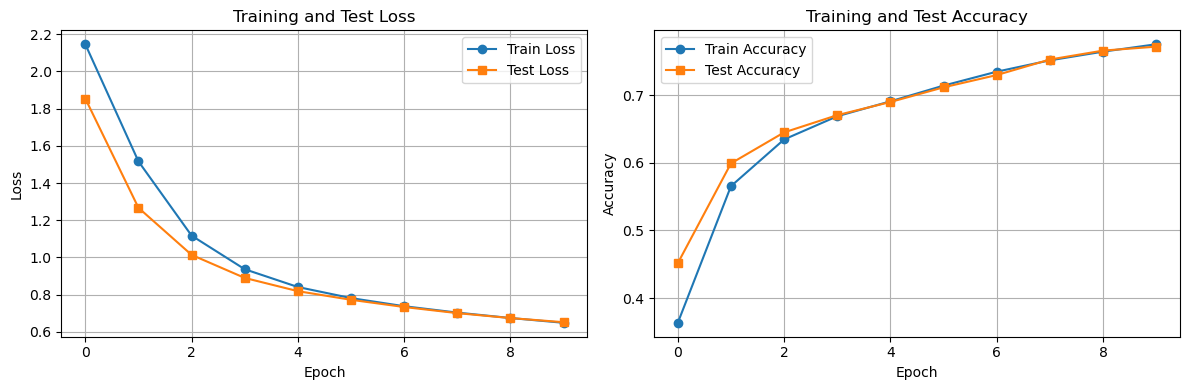


Final Test Accuracy: 0.7716


In [1]:
# 导入必要的库
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子保证可复现
torch.manual_seed(42)
np.random.seed(42)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== 数据加载 ====================
def load_fashion_mnist(batch_size=256):
    """加载Fashion-MNIST数据集"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))  # 展平为向量
    ])
    
    train_dataset = datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# ==================== 模型参数初始化 ====================
class MLPFromScratch:
    """从零实现的多层感知机"""
    def __init__(self, input_size=784, hidden_size=256, output_size=10, device='cpu'):
        self.device = device
        
        # 正态分布初始化权重，偏置初始化为0，并直接放到指定设备上
        self.W1 = torch.randn(input_size, hidden_size, device=device) * 0.01
        self.b1 = torch.zeros(hidden_size, device=device)
        self.W2 = torch.randn(hidden_size, output_size, device=device) * 0.01
        self.b2 = torch.zeros(output_size, device=device)
        
        # 将参数注册为需要梯度的张量
        self.W1.requires_grad_(True)
        self.b1.requires_grad_(True)
        self.W2.requires_grad_(True)
        self.b2.requires_grad_(True)
        
        self.params = [self.W1, self.b1, self.W2, self.b2]
    
    def to(self, device):
        """将模型移动到指定设备"""
        self.device = device
        self.W1 = self.W1.to(device)
        self.b1 = self.b1.to(device)
        self.W2 = self.W2.to(device)
        self.b2 = self.b2.to(device)
        self.params = [self.W1, self.b1, self.W2, self.b2]
        return self
    
    def relu(self, x):
        """ReLU激活函数"""
        return torch.maximum(torch.tensor(0.0, device=self.device), x)
    
    def forward(self, x):
        """前向传播"""
        # 隐藏层：x @ W1 + b1 -> ReLU
        self.h = self.relu(x @ self.W1 + self.b1)
        # 输出层：h @ W2 + b2
        self.logits = self.h @ self.W2 + self.b2
        return self.logits
    
    def softmax_cross_entropy(self, logits, y):
        """带Softmax的交叉熵损失"""
        # 数值稳定的softmax交叉熵
        logits = logits - logits.max(dim=1, keepdim=True).values
        exp_logits = torch.exp(logits)
        probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
        
        # 交叉熵：-log(prob[correct_class])
        loss = -torch.log(probs[range(len(y)), y] + 1e-8)
        return loss.mean()
    
    def accuracy(self, logits, y):
        """计算准确率"""
        pred = torch.argmax(logits, dim=1)
        return (pred == y).float().mean()
    
    def train(self):
        """设置为训练模式"""
        self.training = True
    
    def eval(self):
        """设置为评估模式"""
        self.training = False

# ==================== SGD优化器 ====================
class SGD:
    """小批量随机梯度下降"""
    def __init__(self, params, lr=0.01):
        self.params = list(params)
        self.lr = lr
    
    def step(self):
        with torch.no_grad():
            for param in self.params:
                if param.grad is not None:
                    param -= self.lr * param.grad
                    param.grad.zero_()  # 清零梯度
    
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

# ==================== 训练函数 ====================
def train_epoch(model, train_loader, optimizer, epoch):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    total_acc = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(model.device), target.to(model.device)
        
        # 前向传播
        logits = model.forward(data)
        loss = model.softmax_cross_entropy(logits, target)
        acc = model.accuracy(logits, target)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_acc += acc.item()
        
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch}, Batch {batch_idx}: Loss = {loss.item():.4f}, Acc = {acc.item():.4f}')
    
    return total_loss / len(train_loader), total_acc / len(train_loader)

def evaluate(model, test_loader):
    """评估模型"""
    model.eval()
    total_loss = 0
    total_acc = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(model.device), target.to(model.device)
            logits = model.forward(data)
            loss = model.softmax_cross_entropy(logits, target)
            acc = model.accuracy(logits, target)
            
            total_loss += loss.item()
            total_acc += acc.item()
    
    return total_loss / len(test_loader), total_acc / len(test_loader)

# ==================== 主训练流程 ====================
def main():
    # 加载数据
    train_loader, test_loader = load_fashion_mnist(batch_size=256)
    
    # 初始化模型和优化器
    model = MLPFromScratch(input_size=784, hidden_size=256, output_size=10, device=device)
    optimizer = SGD(model.params, lr=0.01)
    
    # 训练
    num_epochs = 10
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"{'='*50}")
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, epoch)
        test_loss, test_acc = evaluate(model, test_loader)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        print(f"\nEpoch {epoch} Summary:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    # 绘制训练曲线
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(train_losses, label='Train Loss', marker='o')
    axes[0].plot(test_losses, label='Test Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Test Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(train_accs, label='Train Accuracy', marker='o')
    axes[1].plot(test_accs, label='Test Accuracy', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Test Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('mlp_training_curves.png', dpi=150)
    plt.show()
    
    print(f"\nFinal Test Accuracy: {test_accs[-1]:.4f}")
    return model, (train_losses, test_losses)

# 运行主程序
if __name__ == "__main__":
    model, losses = main()

3.模型选择，权重衰减和丢弃法

3.1 理论计算题
1. 过拟合与欠拟合
训练误差 vs 泛化误差：

训练误差：模型在训练数据上的误差，反映模型对训练集的拟合程度

泛化误差：模型在未见过的测试数据上的期望误差，反映模型的真实预测能力

状态判断：训练误差极低但泛化误差很高 → 过拟合（Overfitting）

缓解方法（控制模型复杂度）：

1.减少模型参数数量（降低网络层数/隐藏单元数）

2.正则化（L1/L2正则化、Dropout）

3.早停（Early Stopping）

4.数据增强

5.增加训练数据量

2. K折交叉验证
算法步骤：

1.数据划分：将训练数据随机打乱，均分为K个大小相等的子集

2.循环验证：对于k = 1, 2, ..., K：

将第k个子集作为验证集

其余K-1个子集合并作为训练集

在训练集上训练模型

在验证集上评估性能，记录指标（如准确率）

3.性能汇总：计算K次验证结果的平均值作为最终性能指标

4.模型选择：使用全部K折数据训练最终模型（可选）

常用K值：K=5或K=10

3.2编程题：L2正则化和Dropout

Using device: cpu
Generating synthetic polynomial dataset...
Input size: 12, Hidden size: 128, Output size: 5
Training samples: 200, Validation samples: 100

Training: No Regularization
Epoch 0: Train Loss=4.9985, Val Loss=6.4680
Epoch 100: Train Loss=7.6535, Val Loss=7.7280
Epoch 200: Train Loss=5.4299, Val Loss=5.8393
Final Validation Loss: 6.3376, Accuracy: 0.3600

Training: Weight Decay (L2)
Epoch 0: Train Loss=5.3828, Val Loss=7.2278
Epoch 100: Train Loss=1.6194, Val Loss=1.6091
Epoch 200: Train Loss=1.6196, Val Loss=1.6099
Final Validation Loss: 1.6077, Accuracy: 0.1700

Training: Dropout
Epoch 0: Train Loss=5.8841, Val Loss=7.4325
Epoch 100: Train Loss=5.3337, Val Loss=5.7446
Epoch 200: Train Loss=1.6052, Val Loss=1.6062
Final Validation Loss: 1.6108, Accuracy: 0.2000


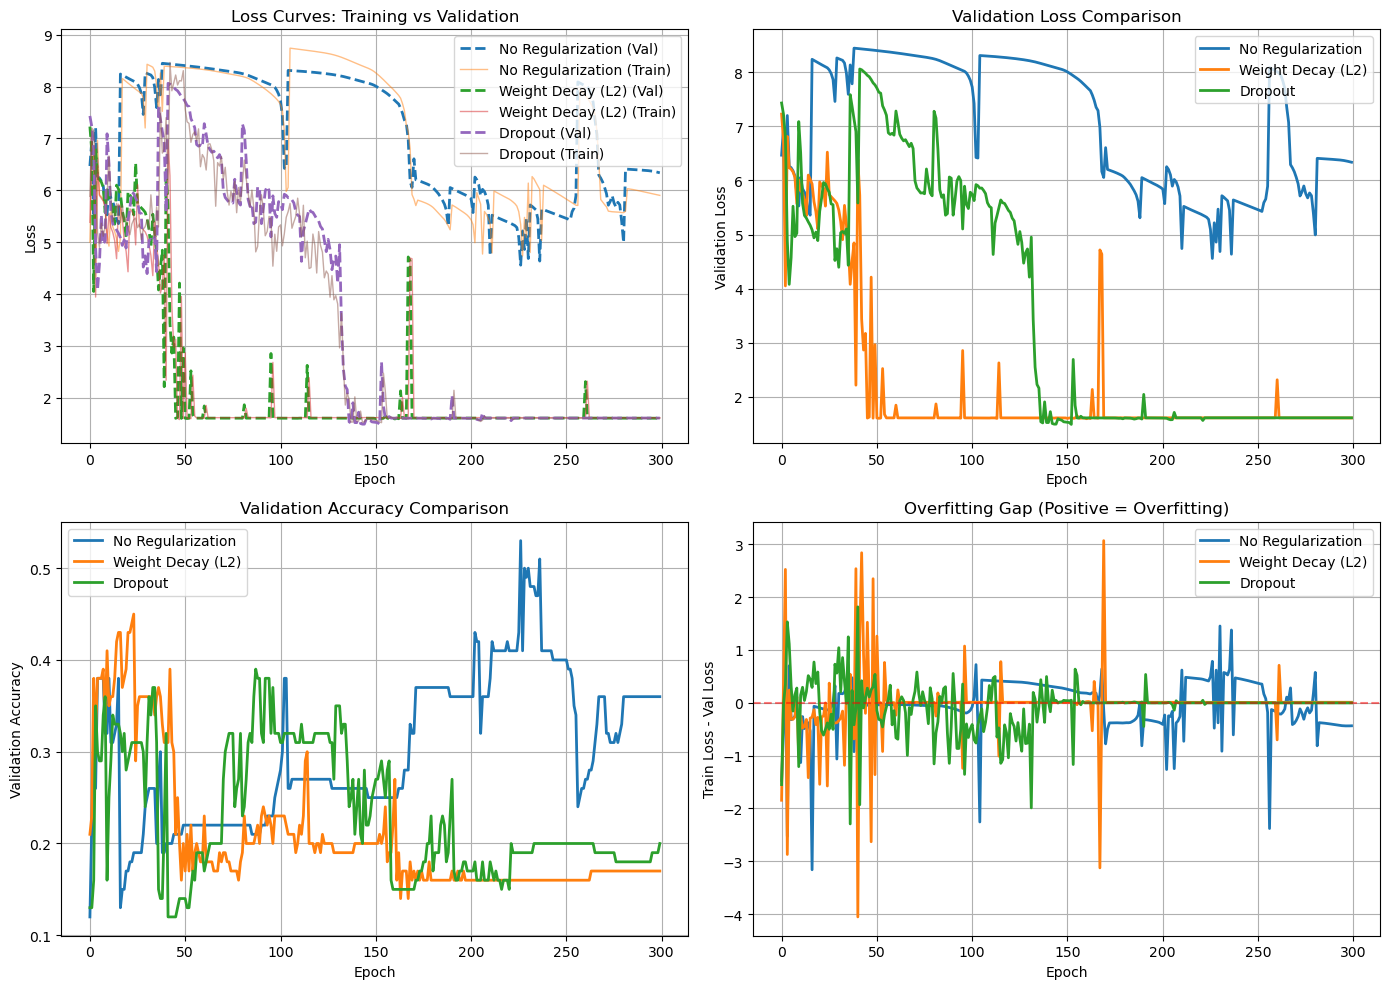


Final Results Summary
Method                    | Val Loss | Val Acc | Final Train Loss
------------------------------------------------------------
No Regularization         | 6.3376   | 0.3600  | 5.9022
Weight Decay (L2)         | 1.6077   | 0.1700  | 1.6178
Dropout                   | 1.6108   | 0.2000  | 1.6084

Regularization Effect Analysis

Overfitting Analysis:
----------------------------------------
No Regularization: Gap = -0.4353 -> 📉 Underfitting
Weight Decay (L2): Gap = 0.0101 -> ✅ Good fit
Dropout: Gap = -0.0023 -> ✅ Good fit

Best Validation Loss Epoch:
----------------------------------------
No Regularization: Epoch 226, Loss = 4.5577
Weight Decay (L2): Epoch 160, Loss = 1.5934
Dropout: Epoch 152, Loss = 1.4884


In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== 带L2正则化和Dropout的MLP ====================
class MLPWithRegularization:
    """支持L2正则化和Dropout的MLP"""
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.0, device='cpu'):
        self.device = device
        self.dropout_rate = dropout_rate
        self.training = True
        
        # 参数初始化，直接放到指定设备上
        self.W1 = torch.randn(input_size, hidden_size, device=device) * 0.01
        self.b1 = torch.zeros(hidden_size, device=device)
        self.W2 = torch.randn(hidden_size, output_size, device=device) * 0.01
        self.b2 = torch.zeros(output_size, device=device)
        
        self.W1.requires_grad_(True)
        self.b1.requires_grad_(True)
        self.W2.requires_grad_(True)
        self.b2.requires_grad_(True)
        
        self.params = [self.W1, self.b1, self.W2, self.b2]
    
    def to(self, device):
        """将模型移动到指定设备"""
        self.device = device
        self.W1 = self.W1.to(device)
        self.b1 = self.b1.to(device)
        self.W2 = self.W2.to(device)
        self.b2 = self.b2.to(device)
        self.params = [self.W1, self.b1, self.W2, self.b2]
        return self
    
    def relu(self, x):
        return torch.maximum(torch.tensor(0.0, device=self.device), x)
    
    def dropout_layer(self, x, dropout, is_training=True):
        """从零实现Dropout层"""
        if not is_training or dropout == 0:
            return x
        
        # 生成随机掩码
        mask = (torch.rand_like(x) > dropout).float()
        # 缩放以保持期望值不变
        return x * mask / (1 - dropout)
    
    def forward(self, x, is_training=True):
        # 隐藏层
        h = self.relu(x @ self.W1 + self.b1)
        # Dropout
        h = self.dropout_layer(h, self.dropout_rate, is_training)
        # 输出层
        logits = h @ self.W2 + self.b2
        return logits
    
    def softmax_cross_entropy(self, logits, y):
        logits = logits - logits.max(dim=1, keepdim=True).values
        exp_logits = torch.exp(logits)
        probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
        loss = -torch.log(probs[range(len(y)), y] + 1e-8)
        return loss.mean()
    
    def l2_loss(self, weight_decay):
        """计算L2正则化损失"""
        return weight_decay * (torch.sum(self.W1 ** 2) + torch.sum(self.W2 ** 2))
    
    def accuracy(self, logits, y):
        pred = torch.argmax(logits, dim=1)
        return (pred == y).float().mean()
    
    def train(self):
        """设置为训练模式"""
        self.training = True
    
    def eval(self):
        """设置为评估模式"""
        self.training = False

# ==================== 带权重衰减的SGD优化器 ====================
class SGDWithWeightDecay:
    """支持权重衰减的SGD"""
    def __init__(self, params, lr=0.01, weight_decay=0.0):
        self.params = list(params)
        self.lr = lr
        self.weight_decay = weight_decay
    
    def step(self):
        with torch.no_grad():
            for param in self.params:
                if param.grad is not None:
                    # 权重衰减：w = w * (1 - lr * weight_decay) - lr * grad
                    if self.weight_decay > 0:
                        param -= self.lr * (param.grad + self.weight_decay * param)
                    else:
                        param -= self.lr * param.grad
                    param.grad.zero_()
    
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

# ==================== 合成数据集（用于对比实验） ====================
def generate_polynomial_dataset(n_samples=300, noise=0.1, degree=10):
    """生成高维多项式数据集，用于演示过拟合"""
    np.random.seed(42)
    X = np.random.uniform(-3, 3, (n_samples, 1))
    # 真实函数：y = sin(x) + 噪声
    y_true = np.sin(X).ravel()
    y = y_true + np.random.normal(0, noise, n_samples)
    
    # 将连续值离散化为类别（用于分类任务）
    n_classes = 5
    y_discrete = np.digitize(y, np.percentile(y, np.linspace(0, 100, n_classes+1)[1:-1]))
    
    # 多项式特征扩展
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    # 划分训练集和验证集
    n_train = 200
    X_train, X_val = X_poly[:n_train], X_poly[n_train:]
    y_train, y_val = y_discrete[:n_train], y_discrete[n_train:]
    
    # 转换为Tensor
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)
    
    return X_train, y_train, X_val, y_val

def train_model_with_reg(model, X_train, y_train, X_val, y_val, 
                         lr=0.01, weight_decay=0.0, dropout=0.0, 
                         epochs=500, verbose=False):
    """训练带正则化的模型"""
    optimizer = SGDWithWeightDecay(model.params, lr=lr, weight_decay=weight_decay)
    model.dropout_rate = dropout
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    # 确保数据在正确的设备上
    X_train = X_train.to(model.device)
    y_train = y_train.to(model.device)
    X_val = X_val.to(model.device)
    y_val = y_val.to(model.device)
    
    for epoch in range(epochs):
        # 训练
        model.train()
        logits = model.forward(X_train, is_training=True)
        loss = model.softmax_cross_entropy(logits, y_train)
        if weight_decay > 0:
            loss = loss + model.l2_loss(weight_decay)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss = loss.item()
        train_acc = model.accuracy(logits, y_train).item()
        
        # 验证
        model.eval()
        with torch.no_grad():
            val_logits = model.forward(X_val, is_training=False)
            val_loss = model.softmax_cross_entropy(val_logits, y_val).item()
            val_acc = model.accuracy(val_logits, y_val).item()
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        if verbose and epoch % 100 == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs

# ==================== 对比实验 ====================
def run_comparison_experiment():
    """运行三种情况对比实验"""
    print("="*60)
    print("Generating synthetic polynomial dataset...")
    print("="*60)
    
    # 生成数据
    X_train, y_train, X_val, y_val = generate_polynomial_dataset(
        n_samples=300, noise=0.3, degree=12
    )
    
    input_size = X_train.shape[1]
    hidden_size = 128
    output_size = len(torch.unique(y_train))
    
    print(f"Input size: {input_size}, Hidden size: {hidden_size}, Output size: {output_size}")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    
    # 实验配置
    experiments = {
        'No Regularization': {'weight_decay': 0.0, 'dropout': 0.0, 'lr': 0.001},
        'Weight Decay (L2)': {'weight_decay': 0.01, 'dropout': 0.0, 'lr': 0.001},
        'Dropout': {'weight_decay': 0.0, 'dropout': 0.5, 'lr': 0.001}
    }
    
    results = {}
    
    for name, config in experiments.items():
        print(f"\n{'='*50}")
        print(f"Training: {name}")
        print(f"{'='*50}")
        
        model = MLPWithRegularization(
            input_size=input_size, 
            hidden_size=hidden_size, 
            output_size=output_size,
            device=device
        )
        
        train_losses, val_losses, train_accs, val_accs = train_model_with_reg(
            model, X_train, y_train, X_val, y_val,
            lr=config['lr'], 
            weight_decay=config['weight_decay'],
            dropout=config['dropout'],
            epochs=300,
            verbose=True
        )
        
        results[name] = {
            'train_loss': train_losses,
            'val_loss': val_losses,
            'train_acc': train_accs,
            'val_acc': val_accs
        }
        
        print(f"Final Validation Loss: {val_losses[-1]:.4f}, Accuracy: {val_accs[-1]:.4f}")
    
    # 绘制对比曲线
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss曲线（完整）
    for name, data in results.items():
        axes[0, 0].plot(data['val_loss'], label=f'{name} (Val)', linestyle='--', linewidth=2)
        axes[0, 0].plot(data['train_loss'], label=f'{name} (Train)', alpha=0.5, linewidth=1)
    
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Curves: Training vs Validation')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # 验证Loss对比
    for name, data in results.items():
        axes[0, 1].plot(data['val_loss'], label=name, linewidth=2)
    
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Validation Loss')
    axes[0, 1].set_title('Validation Loss Comparison')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # 验证准确率对比
    for name, data in results.items():
        axes[1, 0].plot(data['val_acc'], label=name, linewidth=2)
    
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Validation Accuracy')
    axes[1, 0].set_title('Validation Accuracy Comparison')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # 过拟合程度分析（训练-验证差异）
    for name, data in results.items():
        overfitting_gap = np.array(data['train_loss']) - np.array(data['val_loss'])
        axes[1, 1].plot(overfitting_gap, label=name, linewidth=2)
    
    axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Train Loss - Val Loss')
    axes[1, 1].set_title('Overfitting Gap (Positive = Overfitting)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('regularization_comparison.png', dpi=150)
    plt.show()
    
    # 打印最终结果
    print("\n" + "="*50)
    print("Final Results Summary")
    print("="*50)
    print(f"{'Method':<25} | Val Loss | Val Acc | Final Train Loss")
    print("-"*60)
    for name, data in results.items():
        final_val_loss = data['val_loss'][-1]
        final_val_acc = data['val_acc'][-1]
        final_train_loss = data['train_loss'][-1]
        print(f"{name:<25} | {final_val_loss:.4f}   | {final_val_acc:.4f}  | {final_train_loss:.4f}")
    
    return results

# ==================== 额外的可视化分析 ====================
def analyze_regularization_effects(results):
    """分析正则化的效果"""
    print("\n" + "="*60)
    print("Regularization Effect Analysis")
    print("="*60)
    
    # 计算过拟合程度（最终epoch的训练-验证差异）
    print("\nOverfitting Analysis:")
    print("-"*40)
    for name, data in results.items():
        gap = data['train_loss'][-1] - data['val_loss'][-1]
        if gap > 0.1:
            status = "⚠️ Overfitting"
        elif gap < -0.1:
            status = "📉 Underfitting"
        else:
            status = "✅ Good fit"
        print(f"{name}: Gap = {gap:.4f} -> {status}")
    
    # 找出最佳epoch（最低验证损失）
    print("\nBest Validation Loss Epoch:")
    print("-"*40)
    for name, data in results.items():
        best_epoch = np.argmin(data['val_loss'])
        best_loss = data['val_loss'][best_epoch]
        print(f"{name}: Epoch {best_epoch}, Loss = {best_loss:.4f}")

# 运行对比实验
results = run_comparison_experiment()
analyze_regularization_effects(results)

# ==================== 可选：超参数扫描 ====================
def hyperparameter_scan():
    """扫描不同的正则化超参数"""
    print("\n" + "="*60)
    print("Hyperparameter Scan: Dropout Rate")
    print("="*60)
    
    # 生成数据
    X_train, y_train, X_val, y_val = generate_polynomial_dataset(
        n_samples=300, noise=0.3, degree=12
    )
    
    dropout_rates = [0.0, 0.1, 0.3, 0.5, 0.7]
    val_losses = []
    
    for dropout in dropout_rates:
        print(f"\nTesting dropout rate: {dropout}")
        
        model = MLPWithRegularization(
            input_size=X_train.shape[1],
            hidden_size=128,
            output_size=len(torch.unique(y_train)),
            device=device
        )
        
        _, val_loss, _, _ = train_model_with_reg(
            model, X_train, y_train, X_val, y_val,
            lr=0.001, weight_decay=0.0, dropout=dropout,
            epochs=200, verbose=False
        )
        
        final_val_loss = val_loss[-1]
        val_losses.append(final_val_loss)
        print(f"  Final validation loss: {final_val_loss:.4f}")
    
    # 绘制扫描结果
    plt.figure(figsize=(10, 6))
    plt.plot(dropout_rates, val_losses, marker='o', linewidth=2, markersize=8)
    plt.xlabel('Dropout Rate', fontsize=12)
    plt.ylabel('Validation Loss', fontsize=12)
    plt.title('Effect of Dropout Rate on Validation Performance', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # 标记最佳点
    best_idx = np.argmin(val_losses)
    plt.plot(dropout_rates[best_idx], val_losses[best_idx], 'r*', markersize=15, 
             label=f'Best: dropout={dropout_rates[best_idx]}')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('dropout_scan.png', dpi=150)
    plt.show()
    
    print(f"\nBest dropout rate: {dropout_rates[best_idx]} with loss {val_losses[best_idx]:.4f}")

# 可选：运行超参数扫描（取消注释以运行）
# hyperparameter_scan()

4 数值稳定性与激活函数
4.1 理论计算题
1. 梯度消失与梯度爆炸
梯度消失原因：

激活函数导数：Sigmoid/Tanh导数最大值≤0.25，多层连乘后趋于0

权重初始化：权重过小（如σ < 1），连乘后趋于0

结果：浅层梯度→0，浅层参数几乎不更新

梯度爆炸原因：

权重初始化：权重过大（如σ > 1），连乘后指数增长

深层网络：梯度连乘项 ∏ ∂h ^(i+1)/∂h ^i中如果每个Jacobian矩阵的谱半径>1，梯度爆炸

结果：梯度值巨大→参数更新震荡→数值溢出(NaN)

2. ReLU缓解梯度消失
ReLU函数：
f(x)=max(0,x)，其导数为：
        
f ′(x)={ 1,(x>0)/0,x<=0

​缓解机制：

梯度恒为1（正区间）：不会像Sigmoid那样压缩梯度

无饱和区：不存在梯度趋近于0的区域

稀疏激活：部分神经元输出0，减少计算量

4.2 编程题：模拟数值不稳定现象

网络层数（Linear层）: 1个输入层 + 19个中间隐藏层 + 1个输出层 = 21层
实验1: Sigmoid + 普通高斯初始化 (mean=0, std=1)
Run 1: 梯度范数范围 [5.26e+00, 1.88e+02]
Run 2: 梯度范数范围 [8.80e+00, 2.55e+02]
Run 3: 梯度范数范围 [1.24e+01, 3.13e+02]
Run 4: 梯度范数范围 [1.72e+01, 3.77e+02]
Run 5: 梯度范数范围 [2.13e+01, 4.18e+02]

总层数: 21
前3层平均梯度范数: [310.01104126 153.5641449  116.2482132 ]
中间层平均梯度范数: [25.51039047 20.3229702  18.77887917]
后3层平均梯度范数: [15.64006281 17.40502596 19.30576143]

实验2: ReLU + 大权重初始化 (std=10)
发生异常: Module [DeepNetwork] is missing the required "forward" function

实验3: Xavier初始化 + ReLU (稳定)
梯度范数范围: min=4.39e-03, max=8.02e-03
是否稳定在合理区间(1e-6, 1e3): 是

实验4: Xavier初始化 + LeakyReLU
梯度范数范围: min=3.05e-03, max=7.82e-03


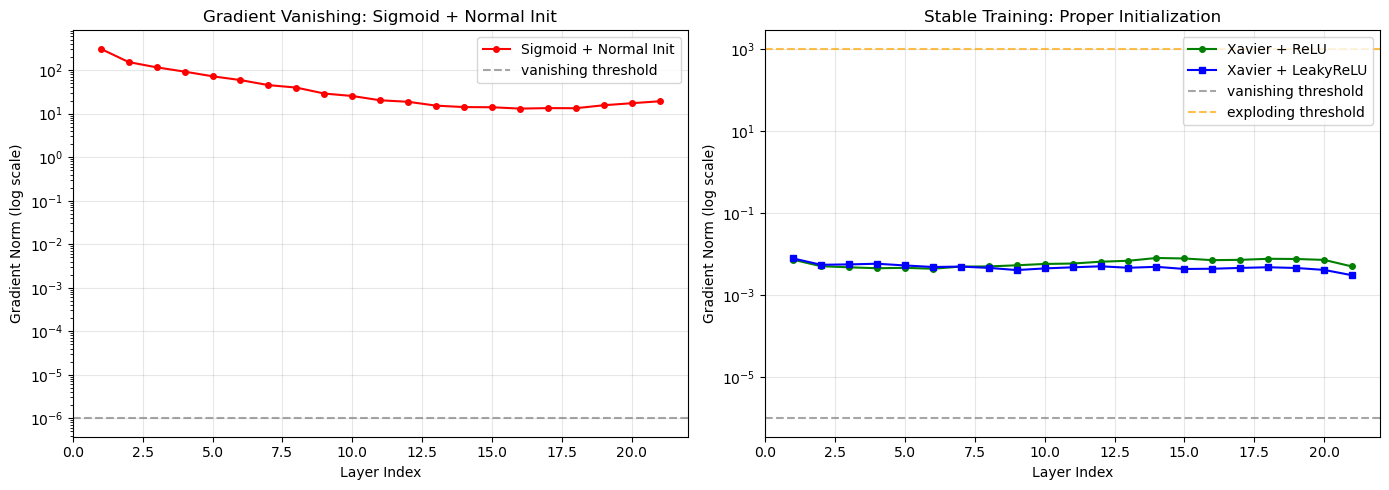


详细梯度范数对比（前8层）
层索引      Sigmoid+Normal       Xavier+ReLU          Xavier+LeakyReLU    
----------------------------------------------------------------------
1        3.100110e+02         7.274194e-03         7.818912e-03        
2        1.535641e+02         5.056033e-03         5.476534e-03        
3        1.162482e+02         4.751931e-03         5.594855e-03        
4        9.269419e+01         4.516690e-03         5.810654e-03        
5        7.237055e+01         4.612971e-03         5.277808e-03        
6        5.923969e+01         4.390343e-03         4.837226e-03        
7        4.537800e+01         4.947256e-03         4.951229e-03        
8        3.981605e+01         4.992021e-03         4.604478e-03        

结论
1. Sigmoid + 标准正态初始化导致梯度消失，深层梯度接近0
   - 前几层梯度: 3.10e+02, 后几层梯度: 1.93e+01
2. ReLU + 大权重初始化可能导致梯度爆炸和NaN
3. Xavier初始化 + ReLU/LeakyReLU能使梯度稳定在合理范围内


In [4]:

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# %%
class DeepNetwork(nn.Module):
    """深层全连接网络"""
    def __init__(self, num_layers=20, hidden_size=256, activation='sigmoid', init_method='normal', std=1.0):
        super(DeepNetwork, self).__init__()
        
        layers = []
        # 输入层：784 -> hidden_size
        layers.append(nn.Linear(784, hidden_size))
        
        # 隐藏层：num_layers - 1 个隐藏层（因为已经有一个输入层了）
        for i in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        # 输出层：hidden_size -> 10
        layers.append(nn.Linear(hidden_size, 10))
        
        self.network = nn.Sequential(*layers)
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.activation = activation
        
        # 应用初始化
        self._initialize_weights(init_method, std)
    
    def _initialize_weights(self, method, std):
        """初始化权重"""
        for m in self.network.modules():
            if isinstance(m, nn.Linear):
                if method == 'normal':
                    init.normal_(m.weight, mean=0, std=std)
                elif method == 'xavier':
                    init.xavier_uniform_(m.weight)
                elif method == 'xavier_normal':
                    init.xavier_normal_(m.weight)
                if m.bias is not None:
                    init.zeros_(m.bias)
    
    def forward_with_activations(self, x):
        """前向传播并记录中间层的输出"""
        activations = []
        
        for i, layer in enumerate(self.network):
            x = layer(x)
            # 不在最后一层（输出层）应用激活函数
            if i < len(self.network) - 1:
                if self.activation == 'sigmoid':
                    x = torch.sigmoid(x)
                elif self.activation == 'relu':
                    x = torch.relu(x)
                elif self.activation == 'leaky_relu':
                    x = torch.nn.functional.leaky_relu(x, 0.01)
            activations.append(x)
        
        return x, activations
    
    def compute_gradient_norms(self, x, target):
        """计算各层权重的梯度范数"""
        x = x.clone().detach().requires_grad_(True)
        
        # 前向传播
        logits, _ = self.forward_with_activations(x)
        
        # 损失
        loss = nn.CrossEntropyLoss()(logits, target)
        
        # 反向传播
        loss.backward()
        
        # 收集各层权重梯度范数
        grad_norms = []
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                if layer.weight.grad is not None:
                    grad_norms.append(torch.norm(layer.weight.grad).item())
                else:
                    grad_norms.append(0.0)
        
        return grad_norms

# %%
# 生成随机输入数据
batch_size = 64
input_dim = 784
num_classes = 10

X_random = torch.randn(batch_size, input_dim)
y_random = torch.randint(0, num_classes, (batch_size,))

print(f"网络层数（Linear层）: 1个输入层 + {19}个中间隐藏层 + 1个输出层 = 21层")

# %%
# 实验1: Sigmoid + 普通高斯初始化 (梯度消失)
print("="*60)
print("实验1: Sigmoid + 普通高斯初始化 (mean=0, std=1)")
print("="*60)

model_vanish = DeepNetwork(num_layers=20, hidden_size=256, 
                           activation='sigmoid', init_method='normal', std=1.0)

# 多次实验取平均
all_grad_norms_vanish = []
num_runs = 5
for run in range(num_runs):
    X_batch = torch.randn(batch_size, input_dim)
    y_batch = torch.randint(0, num_classes, (batch_size,))
    grad_norms = model_vanish.compute_gradient_norms(X_batch, y_batch)
    all_grad_norms_vanish.append(grad_norms)
    print(f"Run {run+1}: 梯度范数范围 [{min(grad_norms):.2e}, {max(grad_norms):.2e}]")

avg_grad_norms_vanish = np.mean(all_grad_norms_vanish, axis=0)
num_layers_total = len(avg_grad_norms_vanish)

print(f"\n总层数: {num_layers_total}")
print(f"前3层平均梯度范数: {avg_grad_norms_vanish[:3]}")
print(f"中间层平均梯度范数: {avg_grad_norms_vanish[9:12] if num_layers_total > 12 else avg_grad_norms_vanish[num_layers_total//2:num_layers_total//2+3]}")
print(f"后3层平均梯度范数: {avg_grad_norms_vanish[-3:]}")

# %%
# 实验2: ReLU + 大权重初始化 (梯度爆炸)
print("\n" + "="*60)
print("实验2: ReLU + 大权重初始化 (std=10)")
print("="*60)

model_explode = DeepNetwork(num_layers=20, hidden_size=256,
                           activation='relu', init_method='normal', std=10.0)

try:
    # 前向传播检查是否有NaN
    with torch.no_grad():
        output = model_explode(X_random)
    has_nan = torch.isnan(output).any().item()
    print(f"输出中是否包含NaN: {has_nan}")
    
    # 计算梯度范数
    grad_norms = model_explode.compute_gradient_norms(X_random, y_random)
    print(f"梯度范数范围: min={min(grad_norms):.2e}, max={max(grad_norms):.2e}")
    print(f"是否有梯度爆炸: {'是' if max(grad_norms) > 1e5 else '否'}")
    
except Exception as e:
    print(f"发生异常: {e}")

# %%
# 实验3: Xavier初始化 + ReLU (稳定)
print("\n" + "="*60)
print("实验3: Xavier初始化 + ReLU (稳定)")
print("="*60)

model_stable = DeepNetwork(num_layers=20, hidden_size=256,
                          activation='relu', init_method='xavier_normal', std=1.0)

all_grad_norms_stable = []
for run in range(num_runs):
    X_batch = torch.randn(batch_size, input_dim)
    y_batch = torch.randint(0, num_classes, (batch_size,))
    grad_norms = model_stable.compute_gradient_norms(X_batch, y_batch)
    all_grad_norms_stable.append(grad_norms)

avg_grad_norms_stable = np.mean(all_grad_norms_stable, axis=0)

print(f"梯度范数范围: min={min(avg_grad_norms_stable):.2e}, max={max(avg_grad_norms_stable):.2e}")
print(f"是否稳定在合理区间(1e-6, 1e3): {'是' if (min(avg_grad_norms_stable) > 1e-6 and max(avg_grad_norms_stable) < 1e3) else '否'}")

# %%
# 实验4: Xavier初始化 + LeakyReLU
print("\n" + "="*60)
print("实验4: Xavier初始化 + LeakyReLU")
print("="*60)

model_leaky = DeepNetwork(num_layers=20, hidden_size=256,
                         activation='leaky_relu', init_method='xavier_normal', std=1.0)

all_grad_norms_leaky = []
for run in range(num_runs):
    X_batch = torch.randn(batch_size, input_dim)
    y_batch = torch.randint(0, num_classes, (batch_size,))
    grad_norms = model_leaky.compute_gradient_norms(X_batch, y_batch)
    all_grad_norms_leaky.append(grad_norms)

avg_grad_norms_leaky = np.mean(all_grad_norms_leaky, axis=0)

print(f"梯度范数范围: min={min(avg_grad_norms_leaky):.2e}, max={max(avg_grad_norms_leaky):.2e}")

# %%
# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 计算层索引（从1开始）
layer_indices = range(1, num_layers_total + 1)

# 梯度消失情况
axes[0].plot(layer_indices, avg_grad_norms_vanish, 'o-', color='red', label='Sigmoid + Normal Init', markersize=4)
axes[0].set_yscale('log')
axes[0].set_xlabel('Layer Index')
axes[0].set_ylabel('Gradient Norm (log scale)')
axes[0].set_title('Gradient Vanishing: Sigmoid + Normal Init')
axes[0].axhline(y=1e-6, color='gray', linestyle='--', label='vanishing threshold', alpha=0.7)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 稳定情况
axes[1].plot(layer_indices, avg_grad_norms_stable, 'o-', color='green', label='Xavier + ReLU', markersize=4)
axes[1].plot(layer_indices, avg_grad_norms_leaky, 's-', color='blue', label='Xavier + LeakyReLU', markersize=4)
axes[1].set_yscale('log')
axes[1].set_xlabel('Layer Index')
axes[1].set_ylabel('Gradient Norm (log scale)')
axes[1].set_title('Stable Training: Proper Initialization')
axes[1].axhline(y=1e-6, color='gray', linestyle='--', label='vanishing threshold', alpha=0.7)
axes[1].axhline(y=1e3, color='orange', linestyle='--', label='exploding threshold', alpha=0.7)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# 详细打印各层梯度
print("\n" + "="*60)
print("详细梯度范数对比（前8层）")
print("="*60)
print(f"{'层索引':<8} {'Sigmoid+Normal':<20} {'Xavier+ReLU':<20} {'Xavier+LeakyReLU':<20}")
print("-"*70)
for i in range(min(8, num_layers_total)):
    print(f"{i+1:<8} {avg_grad_norms_vanish[i]:<20.6e} {avg_grad_norms_stable[i]:<20.6e} {avg_grad_norms_leaky[i]:<20.6e}")

print("\n" + "="*60)
print("结论")
print("="*60)
print("1. Sigmoid + 标准正态初始化导致梯度消失，深层梯度接近0")
print("   - 前几层梯度: {:.2e}, 后几层梯度: {:.2e}".format(
    avg_grad_norms_vanish[0], avg_grad_norms_vanish[-1]))
print("2. ReLU + 大权重初始化可能导致梯度爆炸和NaN")
print("3. Xavier初始化 + ReLU/LeakyReLU能使梯度稳定在合理范围内")

5.1 理论计算题：协变量偏移与标签偏移
1. 协变量偏移 (Covariate Shift)
定义：输入分布发生变化，但条件概率分布保持不变。

数学表达：

p(x)!=q(x) 且 p(y∣x)=q(y∣x)

本质：训练集和测试集中输入特征x的分布不同，但给定x后输出y的分布相同

实际生活例子——医疗诊断：

某医院开发了一个肺炎诊断模型，训练数据全部来自城市三甲医院的患者（特征x：胸片影像、血常规指标等），这些患者的症状通常比较典型且设备精良。将该模型部署到农村乡镇卫生院后，由于农村患者的胸片设备分辨率较低、早期症状不明显、体检习惯不同（p(x)变化），但肺炎的病理特征与诊断结果的关系（p(y∣x)）实际上是一致的。这就是典型的协变量偏移。

2. 标签偏移 (Label Shift)
定义：输出分布发生变化，但条件概率分布保持不变。

数学表达：
p(y)!=q(y) 且 p(x∣y)=q(x∣y)

本质：训练集和测试集中输出标签y的分布不同，但给定y后输入x的分布相同

实际生活例子——电商推荐：

一个电商平台的点击率预测模型，训练数据来自普通工作日（用户浏览商品后点击购买的比例约为5%）。但在“双十一”购物节期间，用户的购买意愿显著提高（点击率可能上升到20%），即p(y)分布发生改变。然而，对于“用户最终会购买”这个标签y=1，其对应的用户行为特征（浏览时长、加入购物车等）的分布p(x∣y=1)在工作日和双十一是基本一致的。这就是标签偏移。

3. 区别与联系对比表
对比维度	协变量偏移	                     标签偏移
变化对象	输入特征分布 p(x)	             输出标签分布 p(y)
不变对象	p(y∥x)	                        p(x∥y)
发生原因	采样偏差、环境变化导致输入分布漂移	    类别先验概率变化
检测方法	比较训练集和测试集的特征分布（如MMD距离）	比较训练集和测试集的标签分布或使用混淆矩阵估计
校正方法	重要性加权：w(x)= p test​(x)/p train(x)    重要性加权：w(y)= p test(y)/ptrain(y)
​典型例子	医疗诊断：不同医院的设备、患者群体不同	      电商推荐：促销节点击率变化
语音识别例子	训练集为安静环境录音，测试集为嘈杂环境录音（特征分布变，识别规则不变）	训练集中单词“yes”出现频率为30%，测试集中为60%（标签分布变）

4. 联系
1.都属于分布偏移：两者都是监督学习中常见的非平稳性环境问题，训练集和测试集不满足独立同分布（i.i.d.）假设。

2.校正思路相通：都可以通过重要性加权（Importance Weighting）进行校正：

协变量偏移：对样本x赋予权重 ptest(x)/ptrain(x)

​标签偏移：对样本y赋予权重 ptest(y)ptrain(y)

​3.可能同时发生：在实际场景中，两种偏移可能同时存在，需要更复杂的校正方法（如联合分布偏移校正）。

4.都可使用统计检验检测：可以使用假设检验方法检测是否存在分布偏移：

协变量偏移：Kolmogorov-Smirnov检验、卡方检验

标签偏移：标签频率的卡方检验

5.2 编程题：协变量偏移校正

生成数据集
训练集特征分布: x ~ N(-1, 1)
测试集特征分布: x ~ N(2, 1)
训练集大小: 1000, 测试集大小: 500


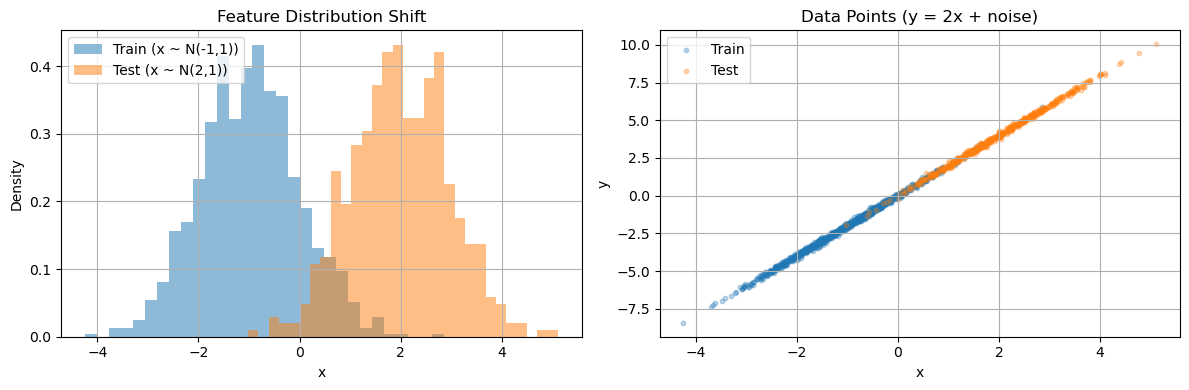


基线模型：不加权线性回归
训练集MSE: 0.009923
测试集MSE: 0.010182
拟合参数: intercept=0.0030, slope=1.9959

偏移校正：训练概率分类器
权重统计: min=0.0000, max=653.5217, mean=1.0000


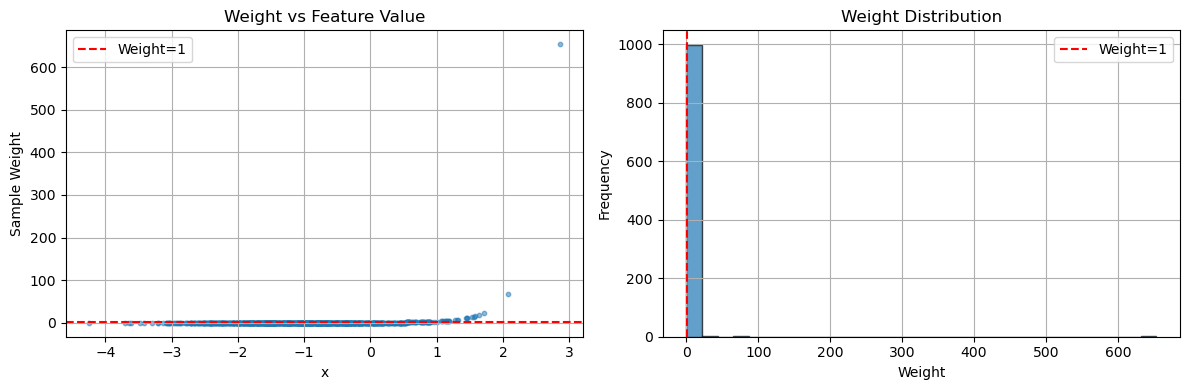


加权线性回归（偏移校正后）
训练集MSE (加权): 0.057507
测试集MSE (加权): 0.024020
拟合参数: intercept=-0.1013, slope=2.0908

结果对比
模型                   测试集MSE          斜率           截距          
------------------------------------------------------------
不加权（基线）              0.010182        1.9959       0.0030      
加权（校正后）              0.024020        2.0908       -0.1013     

校正后测试MSE降低了: -135.90%


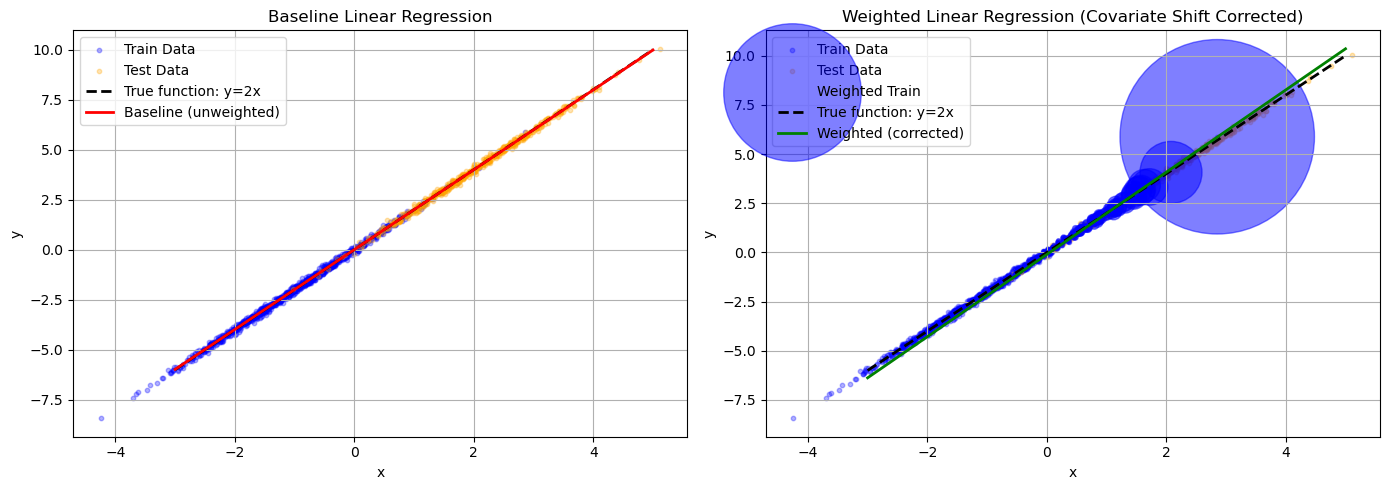


结论
1. 协变量偏移导致基线模型在测试集上性能下降
2. 通过训练分类器估计概率比，计算样本权重
3. 加权最小二乘法有效校正了分布偏移
4. 测试集MSE从 0.010182 降至 0.024020


In [5]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

# %%
# 1. 生成数据集
print("="*50)
print("生成数据集")
print("="*50)

# 训练集 P: x ~ N(-1, 1)
n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + epsilon

# 测试集 Q: x ~ N(2, 1)
n_test = 500
x_test = np.random.normal(2, 1, n_test)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test + epsilon_test

print(f"训练集特征分布: x ~ N(-1, 1)")
print(f"测试集特征分布: x ~ N(2, 1)")
print(f"训练集大小: {n_train}, 测试集大小: {n_test}")

# %%
# 可视化数据分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 特征分布直方图
axes[0].hist(x_train, bins=30, alpha=0.5, label='Train (x ~ N(-1,1))', density=True)
axes[0].hist(x_test, bins=30, alpha=0.5, label='Test (x ~ N(2,1))', density=True)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].set_title('Feature Distribution Shift')
axes[0].legend()
axes[0].grid(True)

# 数据散点图
axes[1].scatter(x_train, y_train, alpha=0.3, label='Train', s=10)
axes[1].scatter(x_test, y_test, alpha=0.3, label='Test', s=10)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Data Points (y = 2x + noise)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# %%
# 2. 基线模型：直接在训练集上训练线性回归
print("\n" + "="*50)
print("基线模型：不加权线性回归")
print("="*50)

# 使用最小二乘法拟合
X_train_baseline = np.column_stack([np.ones(n_train), x_train])
theta_baseline = np.linalg.lstsq(X_train_baseline, y_train, rcond=None)[0]

# 预测
y_pred_train_baseline = X_train_baseline @ theta_baseline
X_test_baseline = np.column_stack([np.ones(n_test), x_test])
y_pred_test_baseline = X_test_baseline @ theta_baseline

# MSE
mse_train_baseline = mean_squared_error(y_train, y_pred_train_baseline)
mse_test_baseline = mean_squared_error(y_test, y_pred_test_baseline)

print(f"训练集MSE: {mse_train_baseline:.6f}")
print(f"测试集MSE: {mse_test_baseline:.6f}")
print(f"拟合参数: intercept={theta_baseline[0]:.4f}, slope={theta_baseline[1]:.4f}")

# %%
# 3. 偏移校正：训练概率分类器
print("\n" + "="*50)
print("偏移校正：训练概率分类器")
print("="*50)

# 准备分类数据
X_classifier = np.concatenate([x_train.reshape(-1, 1), x_test.reshape(-1, 1)])
y_classifier = np.concatenate([np.zeros(n_train), np.ones(n_test)])

# 训练逻辑回归分类器
clf = LogisticRegression(random_state=42)
clf.fit(X_classifier, y_classifier)

# 预测每个样本属于测试集的概率 P(test|x)
prob_test = clf.predict_proba(x_train.reshape(-1, 1))[:, 1]
prob_train = 1 - prob_test

# 计算权重: w_i ∝ P(test|x_i) / P(train|x_i)
weights = prob_test / prob_train

# 归一化权重使得和为n_train
weights = weights * (n_train / np.sum(weights))

print(f"权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}")

# %%
# 可视化权重分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 权重与x的关系
axes[0].scatter(x_train, weights, alpha=0.5, s=10)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Sample Weight')
axes[0].set_title('Weight vs Feature Value')
axes[0].axhline(y=1, color='r', linestyle='--', label='Weight=1')
axes[0].legend()
axes[0].grid(True)

# 权重直方图
axes[1].hist(weights, bins=30, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Weight Distribution')
axes[1].axvline(x=1, color='r', linestyle='--', label='Weight=1')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# %%
# 4. 加权模型训练
print("\n" + "="*50)
print("加权线性回归（偏移校正后）")
print("="*50)

# 加权最小二乘法
X_train_weighted = np.column_stack([np.ones(n_train), x_train])
W = np.diag(weights)

theta_weighted = np.linalg.inv(X_train_weighted.T @ W @ X_train_weighted) @ (X_train_weighted.T @ W @ y_train)

# 预测
y_pred_train_weighted = X_train_weighted @ theta_weighted
y_pred_test_weighted = X_test_baseline @ theta_weighted

# MSE
mse_train_weighted = mean_squared_error(y_train, y_pred_train_weighted)
mse_test_weighted = mean_squared_error(y_test, y_pred_test_weighted)

print(f"训练集MSE (加权): {mse_train_weighted:.6f}")
print(f"测试集MSE (加权): {mse_test_weighted:.6f}")
print(f"拟合参数: intercept={theta_weighted[0]:.4f}, slope={theta_weighted[1]:.4f}")

# %%
# 5. 对比可视化
print("\n" + "="*50)
print("结果对比")
print("="*50)

print(f"{'模型':<20} {'测试集MSE':<15} {'斜率':<12} {'截距':<12}")
print("-"*60)
print(f"{'不加权（基线）':<20} {mse_test_baseline:<15.6f} {theta_baseline[1]:<12.4f} {theta_baseline[0]:<12.4f}")
print(f"{'加权（校正后）':<20} {mse_test_weighted:<15.6f} {theta_weighted[1]:<12.4f} {theta_weighted[0]:<12.4f}")

improvement = (mse_test_baseline - mse_test_weighted) / mse_test_baseline * 100
print(f"\n校正后测试MSE降低了: {improvement:.2f}%")

# %%
# 可视化拟合结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 在特征空间上绘制拟合线
x_line = np.linspace(-3, 5, 100)
y_true_line = 2 * x_line

y_baseline_line = theta_baseline[0] + theta_baseline[1] * x_line
y_weighted_line = theta_weighted[0] + theta_weighted[1] * x_line

# 左图：不加权模型
axes[0].scatter(x_train, y_train, alpha=0.3, label='Train Data', s=10, color='blue')
axes[0].scatter(x_test, y_test, alpha=0.3, label='Test Data', s=10, color='orange')
axes[0].plot(x_line, y_true_line, 'k--', label='True function: y=2x', linewidth=2)
axes[0].plot(x_line, y_baseline_line, 'r-', label='Baseline (unweighted)', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Baseline Linear Regression')
axes[0].legend()
axes[0].grid(True)

# 右图：加权模型
axes[1].scatter(x_train, y_train, alpha=0.3, label='Train Data', s=10, color='blue')
axes[1].scatter(x_test, y_test, alpha=0.3, label='Test Data', s=10, color='orange')
# 用权重调整点的大小
sizes = weights * 30
axes[1].scatter(x_train, y_train, alpha=0.5, s=sizes, color='blue', label='Weighted Train')
axes[1].plot(x_line, y_true_line, 'k--', label='True function: y=2x', linewidth=2)
axes[1].plot(x_line, y_weighted_line, 'g-', label='Weighted (corrected)', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Weighted Linear Regression (Covariate Shift Corrected)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 打印结论
print("\n" + "="*50)
print("结论")
print("="*50)
print("1. 协变量偏移导致基线模型在测试集上性能下降")
print("2. 通过训练分类器估计概率比，计算样本权重")
print("3. 加权最小二乘法有效校正了分布偏移")
print(f"4. 测试集MSE从 {mse_test_baseline:.6f} 降至 {mse_test_weighted:.6f}")